# Cat vs Dog Image Classification Using CNN

#### A Deep Learning Project for Binary Image Classification with Streamlit Deployment

### Objective: Build, train, and deploy a Convolutional Neural Network (CNN) that classifies images as either a Cat or a Dog, complete with performance evaluation and an interactive web interface for real-time predictions.

### Import Libraries

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from  tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten,Dense,Dropout # is used to prevent overfit
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping # 

### step2 : Data Preprocessing

Rescales pixel values from 0–255 down to 0–1, and randomly tweaks training images (zoom/shear/flip) so the model sees more variety — called data augmentation. Test images are only rescaled, kept "normal."


In [5]:
train_gen=ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_gen =ImageDataGenerator(
    rescale=1./255
)
train_path=r"C:\Users\hp\Downloads\training_set\training_set"
test_path=r"C:\Users\hp\Downloads\test_set\test_set"

### Load training dataset
Reads every image in the training folder, resizes to 128×128, batches them by 32. Prints class_indices showing which number means cat vs dog.

In [6]:
train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

print(train_data.class_indices)

Found 8005 images belonging to 2 classes.
{'cats': 0, 'dogs': 1}


### Load testing dataset

Same idea, but for images the model never trains on — used later to check if it really learned, not just memorized.

In [7]:
test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)
print(test_data.class_indices)

Found 2023 images belonging to 2 classes.
{'cats': 0, 'dogs': 1}


### Build the CNN (first conv layers)
Conv2D(32) detects simple patterns (edges, colors); MaxPooling shrinks the image while keeping key details; Conv2D(64) combines those into more complex shapes.



In [8]:
model = Sequential()
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

C:\Users\hp\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Finish the CNN (decision layers)

Another pooling step, then Flatten (turns the grid into one long list), Dense(128) makes sense of it all, Dropout(0.5) randomly disables neurons to avoid overfitting, and the final Dense(1, sigmoid) outputs a single 0–1 score.

In [9]:
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

### Compile the Model

Sets the learning strategy (adam), the error measure (binary_crossentropy), and what to track (accuracy).

In [10]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       7,372,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

### Early stopping

Watches validation loss; stops training automatically if it hasn't improved in 3 epochs, keeping the best version.

In [12]:
es=EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

### train model
The actual learning loop — up to 20 passes (epochs) through the training images, checking itself against test images each time.

In [13]:
history=model.fit(
    train_data,
    validation_data=test_data,
    epochs=20,
    callbacks=[es]
)

Epoch 1/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 135s 525ms/step - accuracy: 0.5953 - loss: 0.6885 - val_accuracy: 0.6480 - val_loss: 0.6230
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 113s 452ms/step - accuracy: 0.6627 - loss: 0.6218 - val_accuracy: 0.7177 - val_loss: 0.5773
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 121s 481ms/step - accuracy: 0.7188 - loss: 0.5635 - val_accuracy: 0.7410 - val_loss: 0.5473
Epoch 4/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 114s 454ms/step - accuracy: 0.7379 - loss: 0.5317 - val_accuracy: 0.7622 - val_loss: 0.4866
Epoch 5/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 114s 453ms/step - accuracy: 0.7638 - loss: 0.4920 - val_accuracy: 0.7706 - val_loss: 0.4780
Epoch 6/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 120s 476ms/step - accuracy: 0.7835 - loss: 0.4566 - val_accuracy: 0.7924 - val_loss: 0.4481
Epoch 8/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 141s 561ms/step - accuracy: 0.7930 - loss: 0.4426 - val_accuracy: 0.7914 - val_loss: 0.4580
Epoch 9/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 140s 556ms/step - accuracy: 0.8252 -

### Accuracy grapgh

Shows training vs. validation accuracy over time — ideally both climb together.



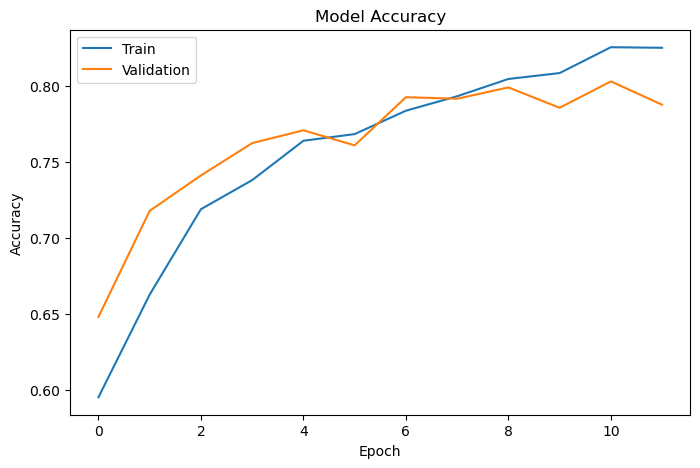

In [24]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

### loss grapgh

Same, but for loss (error) — want both trending down; validation loss rising while training loss falls = overfitting warning sign.


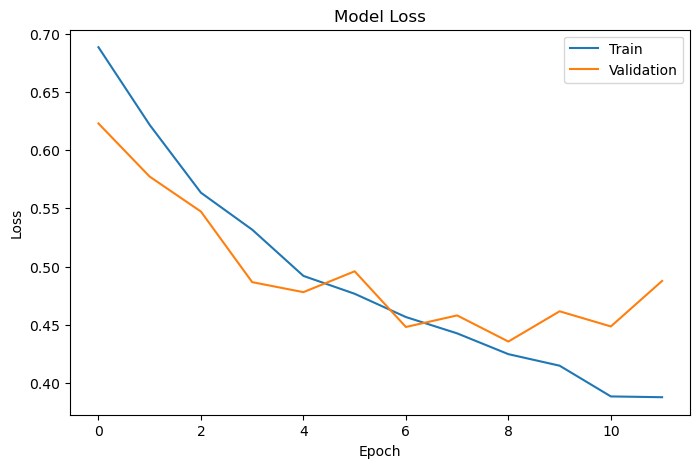

In [25]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()

### evaluate model

accuracy/loss score on the full test set.


In [26]:
loss,acc =model.evaluate(test_data)

print("Accuracy:",acc)
print("Loss:",loss)


64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 198ms/step - accuracy: 0.7988 - loss: 0.4356
Accuracy: 0.7988136410713196
Loss: 0.4355525076389313


In [27]:
# save model
model.save("cat_dog_cnn.keras")
print("Model Saved Successfully")

Model Saved Successfully


In [28]:
# load model
model=load_model("cat_dog_cnn.keras")

### predict new image
Loads a fresh photo, resizes/rescales it the same way as training data, adds a batch dimension, and gets a raw prediction score.

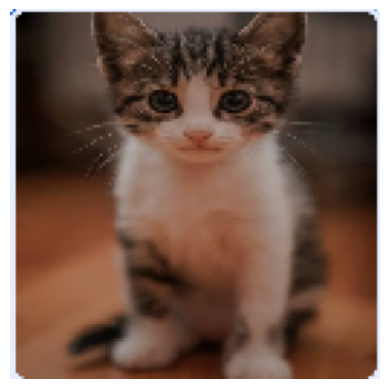

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
prediction Score: 0.7841413


In [29]:
import numpy as np
img_path=r"C:\Users\hp\OneDrive\Gambar\Screenshots\Screenshot 2026-06-19 131331.png"
img=image.load_img(
    img_path,
    target_size=(128,128)
)
plt.imshow(img)
plt.axis("off")
plt.show()

img_arr=image.img_to_array(img)
img_arr=img_arr/255.0
img_arr=np.expand_dims(img_arr, axis = 0)

pred=model.predict(img_arr)
print("prediction Score:",pred[0][0])

In [30]:
# final prediction

if pred[0][0]>0.5:
    print("Dog")
else:
    print("Cat")

Dog


### Predict Another Image (with AVIF Support)
Repeats the same prediction steps, now able to handle AVIF files as well.


In [31]:
pip install pillow-avif-plugin

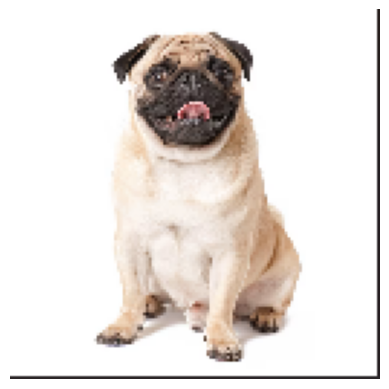

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step
prediction score: 0.74922013
Dog


In [32]:
import pillow_avif
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Load model
model = load_model("cat_dog_cnn.keras")

img_path = r"C:\Users\hp\OneDrive\Gambar\Screenshots\Screenshot 2026-06-25 125703.png"
img = image.load_img(img_path,target_size=(128,128))
plt.imshow(img)
plt.axis("off")
plt.show()

img_arr=image.img_to_array(img)
img_arr=img_arr/255.0
img_arr=np.expand_dims(img_arr,axis=0)

pred=model.predict(img_arr)
print("prediction score:",pred[0][0])

if pred[0][0]>0.5:
    print("Dog")
else:
    print("cat")

## Step 9: Confusion Matrix & Classification Report

Goes beyond one accuracy number: shows exactly how many cats/dogs were correctly identified vs. confused, plus precision/recall per class.

64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 194ms/step


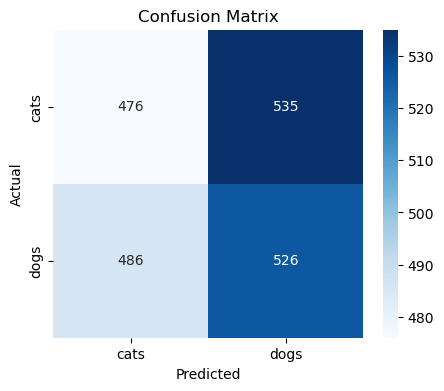

Classification Report:

              precision    recall  f1-score   support

        cats       0.49      0.47      0.48      1011
        dogs       0.50      0.52      0.51      1012

    accuracy                           0.50      2023
   macro avg       0.50      0.50      0.49      2023
weighted avg       0.50      0.50      0.50      2023

Accuracy: 0.495304003954523


In [33]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns

# Reset generator so predictions line up with true labels in order
test_data.reset()
y_true = test_data.classes
y_prob = model.predict(test_data, verbose=1).ravel()
y_pred = (y_prob > 0.5).astype(int)

labels = list(test_data.class_indices.keys())  # e.g. ['cats', 'dogs']

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=labels))
print("Accuracy:", accuracy_score(y_true, y_pred))


### Streamlit Application

### Conclusion
This project teaches a computer to look at a picture and tell whether it's a cat or a dog. It does this using something called a CNN (Convolutional Neural Network) — a type of AI model that's especially good at understanding images.
First, we collect a bunch of cat and dog photos and prepare them so the computer can read them properly. Then we build the CNN — basically teaching it to notice patterns, like shapes, edges, and textures, that are common in cats versus dogs. We show it thousands of examples (this is called training), and over time it gets better at telling the two apart.
Once it's trained, we test it on new photos it's never seen before, to check how accurate it really is. We also look at exactly where it gets confused — does it mix up cats for dogs, or the other way around?
After we're happy with how well it works, we save the trained model so we don't have to retrain it every time. Finally, we wrap it in a simple, friendly web app — so anyone can upload a photo and instantly see whether the model thinks it's a cat or a dog.